conda install transformers

conda install pytorch tensorflow

conda install git+https://github.com/huggingface/transformers

pip freeze

conda install conda-forge/label/cf202003::transformers

conda list

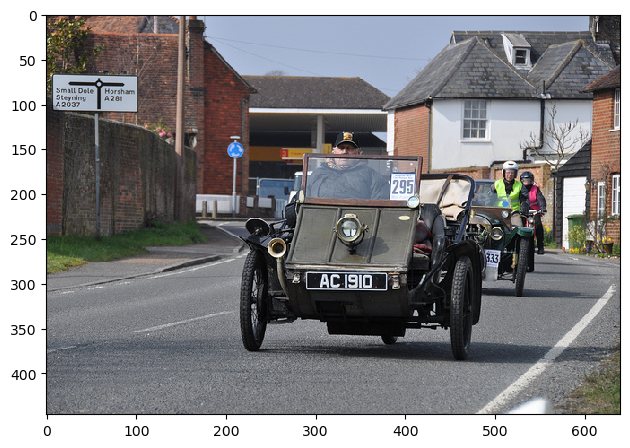

In [95]:
import requests
from skimage import io
#img_url = 'https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg'
#img_url = 'https://fastly.picsum.photos/id/11/200/200.jpg?hmac=LBGO0uEpEmAVS8NeUXMqxcIdHGIcu0JiOb5DJr4mtUI'
img_url = 'http://images.cocodataset.org/test-stuff2017/000000007226.jpg'
image = io.imread(img_url)
# Display the image
io.imshow(image)
io.show()

In [97]:
from transformers import BlipProcessor, BlipForQuestionAnswering
import torch
# load necessary components: the processor and the model
processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base",force_download=True,device_map="cpu")

def get_answer_blip(model, processor, image, question):
    """Answers the given question and handles all the preprocessing and postprocessing steps"""
    # preprocess the given image and question
    inputs = processor(image, question, return_tensors="pt")
    # generate the answer (get output)
    out = model.generate(**inputs)
    # post-process the output to get human friendly english text
    print(processor.decode(out[0], skip_special_tokens=True))
    return

# sample question 1
question = "how many dogs are in the picture?"
get_answer_blip(model, processor, image, question)

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

none


In [ ]:
# sample question 1
question = "how many dogs are in the picture?"
get_answer_blip(model, processor, image, question)

In [5]:
import requests
from PIL import Image
from transformers import BlipProcessor, BlipForQuestionAnswering
import torch

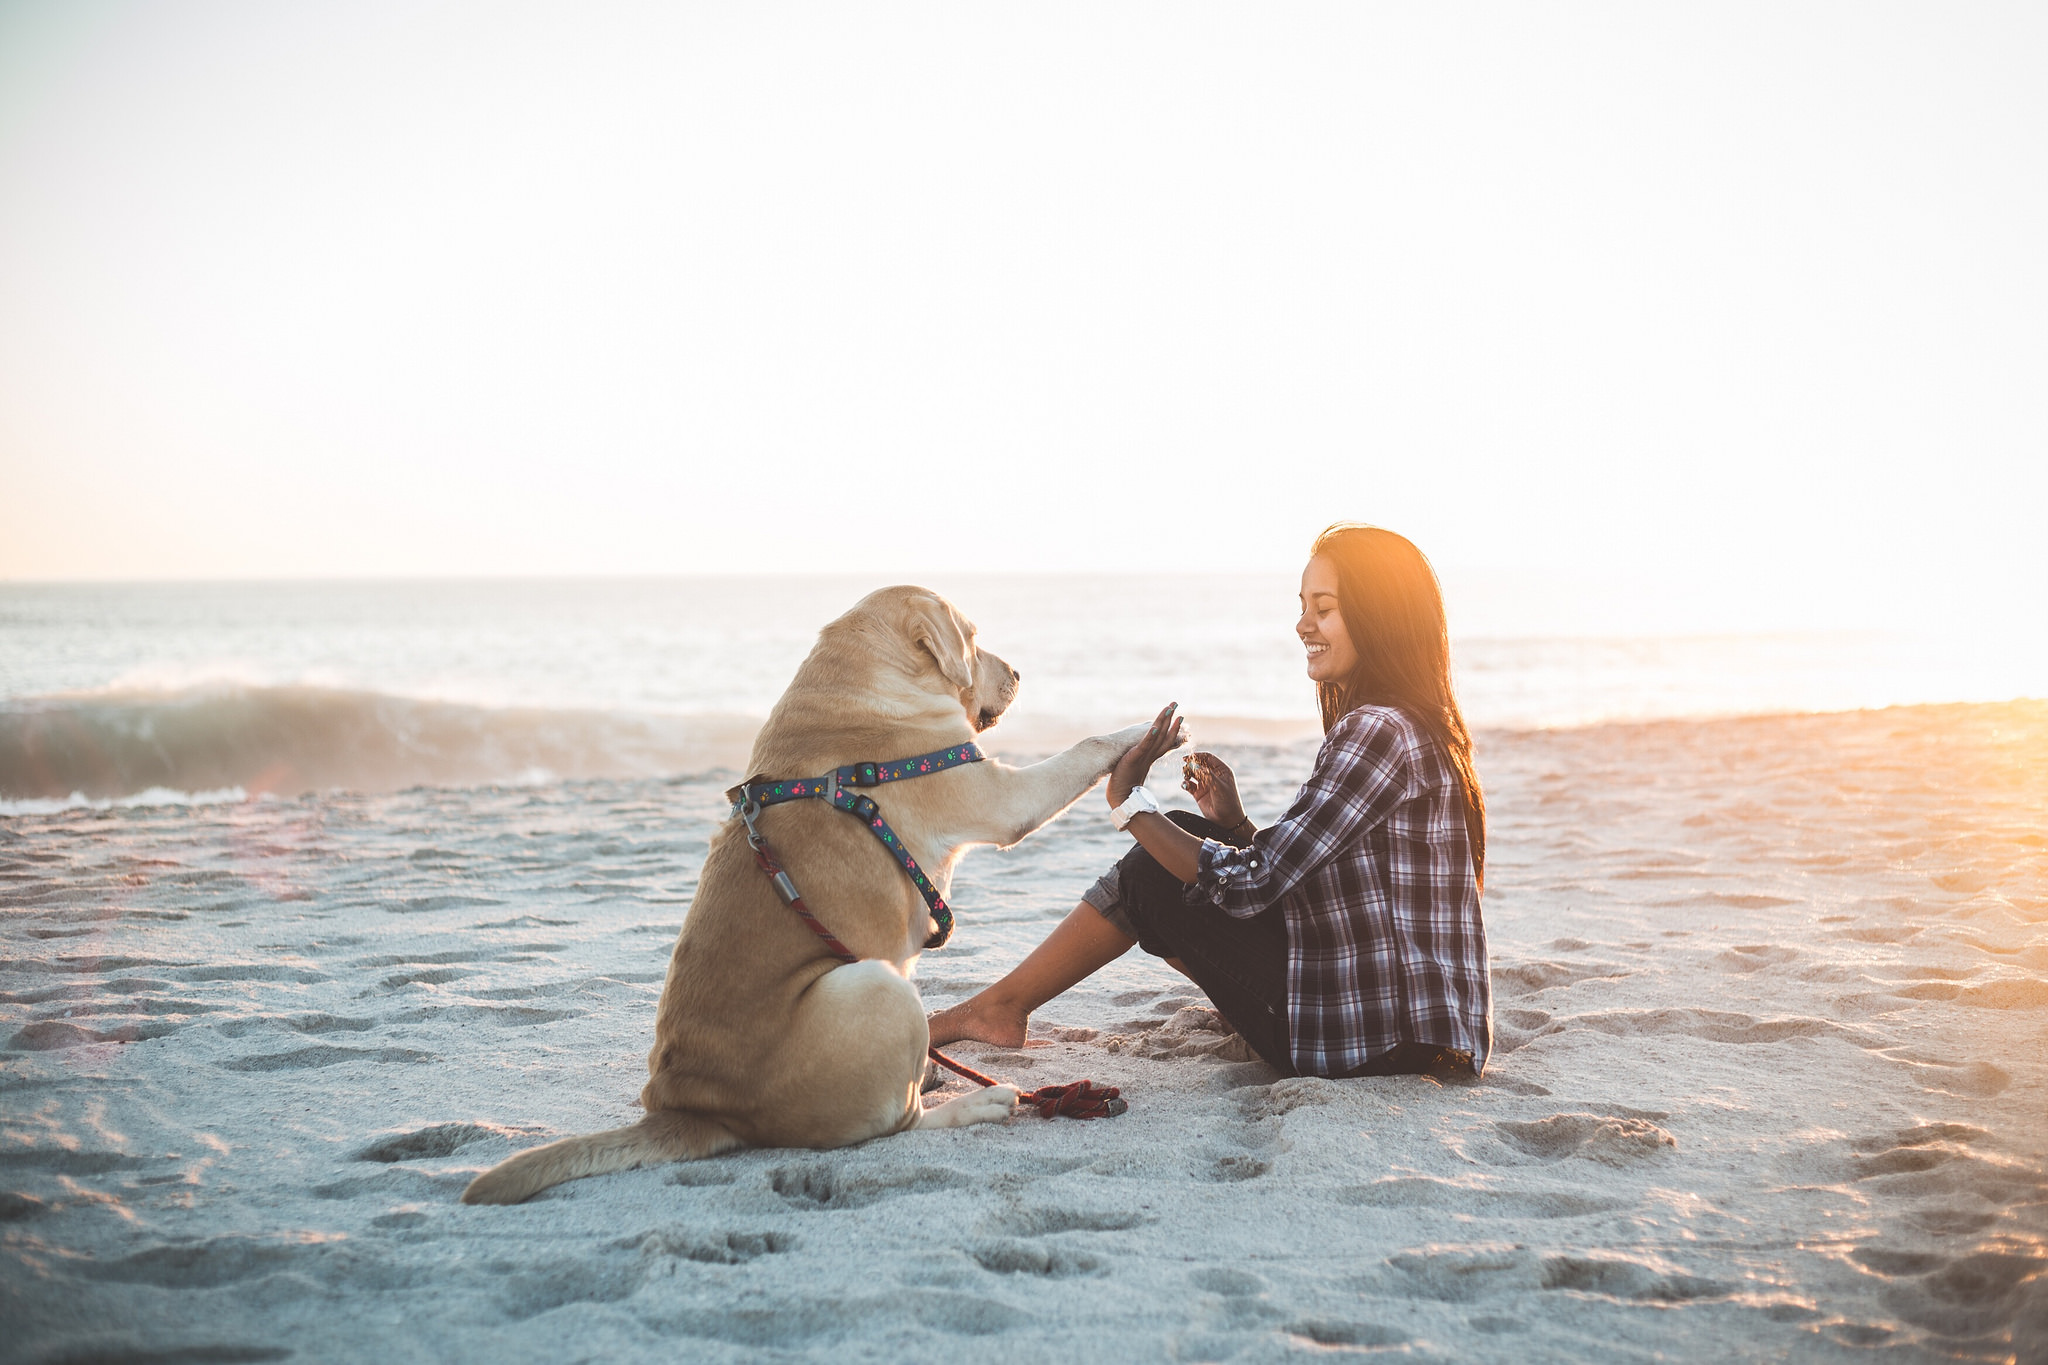

In [117]:
img_url = 'https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg'
image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')
image

In [71]:
# load necessary components: the processor and the model
processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base",force_download=True,device_map="cpu")

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

In [23]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print("running on the GPU")
else:
    device = torch.device("cpu")
    print("running on the CPU")

running on the CPU


In [72]:
def get_answer_blip(model, processor, image, question):
    """Answers the given question and handles all the preprocessing and postprocessing steps"""
    # preprocess the given image and question
    inputs = processor(image, question, return_tensors="pt")
    # generate the answer (get output)
    out = model.generate(**inputs)
    # post-process the output to get human friendly english text
    print(processor.decode(out[0], skip_special_tokens=True))
    return

In [99]:
# sample question 2
question = "how will you describe the picture?"
get_answer_blip(model, processor, image, question)

two men on horses


In [101]:
# sample question 2
question = "Is the sand golden white or black?"
get_answer_blip(model, processor, image, question)

brown


In [103]:
# sample question 3
question = "What Are they doing?"
get_answer_blip(model, processor, image, question)

riding


In [105]:
# sample question 3
question = "where are they?"
get_answer_blip(model, processor, image, question)

on street


In [18]:
question = "how many dogs are in the picture?"
get_answer_blip(model, processor, image, question)

1


In [107]:
# sample question 4
question = "Day or Night?"
get_answer_blip(model, processor, image, question)

day


In [87]:
class BLIP_VQA:
    """Custom implementation of the BLIP model. The code has been adapted from the official transformers implementation"""
    def __init__(self, vision_model, text_encoder, text_decoder, processor):
        """Initialize various objects"""
        self.vision_model = vision_model
        self.text_encoder = text_encoder
        self.text_decoder = text_decoder
        self.processor = processor
    def preprocess(self, img, ques):
        """preprocess the inputs: image, question"""
        # preprocess using the processor
        inputs = self.processor(img, ques, return_tensors='pt')
        # store the pixel values of the image, input IDs (i.e., token IDs) of the question and the attention masks separately
        pixel_values = inputs['pixel_values']
        input_ids = inputs['input_ids']
        attention_mask = inputs['attention_mask'] 
        return pixel_values, input_ids, attention_mask
        

In [57]:
def generate_output(self, pixel_values, input_ids, attention_mask):
    """Generates output from the preprocessed input"""
    # get the vision outputs (i.e., the image embeds)
    vision_outputs = self.vision_model(pixel_values=pixel_values)
    img_embeds = vision_outputs[0]
    # create attention mask with 1s on all the image embedding positions
    img_attention_mask = torch.ones(img_embeds.size()[: -1], dtype=torch.long)
    # encode the questions
    question_outputs = self.text_encoder(input_ids=input_ids,
                                         attention_mask=attention_mask,
                                         encoder_hidden_states=img_embeds,
                                         encoder_attention_mask=img_attention_mask,
                                         return_dict=False)
    # create attention mask with 1s on all the question token IDs positions
    question_embeds = question_outputs[0]
    question_attention_mask = torch.ones(question_embeds.size()[:-1], dtype=torch.long)
    # initialize the answers with the beginning-of-sentence IDs (bos ID)
    bos_ids = torch.full((question_embeds.size(0), 1), fill_value=30522)
    # get output from the decoder. These outputs are the generated IDs
    outputs = self.text_decoder.generate(
        input_ids=bos_ids,
        eos_token_id=102,
        pad_token_id=0,
        encoder_hidden_states=question_embeds,
        encoder_attention_mask=question_attention_mask)
    return outputs

In [89]:
def postprocess(self, outputs):
    """post-process the output generated by the text-decoder"""
    return self.processor.decode(outputs[0], skip_special_tokens=True)

In [ ]:
# sample question 1
ques = "how will you describe the picture?"
print(blip_vqa.get_answer(image, ques))

In [91]:
def get_answer(self, image, ques):
    """Returns human friendly answer to a question"""
    # preprocess
    pixel_values, input_ids, attention_mask = self.preprocess(image, ques)
    # generate output
    outputs = self.generate_output(pixel_values, input_ids, attention_mask)
    # post-process
    answer = self.postprocess(outputs)
    return answer

In [93]:
blip_vqa = BLIP_VQA(vision_model=model.vision_model,
                    text_encoder=model.text_encoder,
                    text_decoder=model.text_decoder,
                    processor=processor)

In [ ]:
import gradio as gr
def greet(name,intensity):
    return "Hello, " + name + "!" * int(intensity)
demo = gr.Interface(fn=greet,inputs=["text","slider"],outputs=["text"],)
demo.launch(server_name="127.0.0.1",share=True)

In [ ]:
BLIP Question Answering - Using gradio interface

In [129]:
import requests
from PIL import Image
from transformers import BlipProcessor, BlipForQuestionAnswering,ViltProcessor, ViltForQuestionAnswering
import torch

#img_url = 'https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg'
#image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')
#image

from transformers import BlipProcessor, BlipForQuestionAnswering
import torch
# load necessary components: the processor and the model
processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base",force_download=True,device_map="cpu")

# Load the processor and model outside of the function to avoid reloading them each time the function is called
#processor_vilt = ViltProcessor.from_pretrained("dandelin/vilt-b32-finetuned-vqa")
#model_vilt = ViltForQuestionAnswering.from_pretrained("dandelin/vilt-b32-finetuned-vqa",device_map="cpu")

def get_answer_blip(image, question):
    """Answers the given question and handles all the preprocessing and postprocessing steps"""
    # preprocess the given image and question
    inputs = processor(images=image, text=question, return_tensors="pt",padding=True)
    # generate the answer (get output)
    out = model.generate(**inputs)
    # post-process the output to get human friendly english text
    print(processor.decode(out[0], skip_special_tokens=True))
    return processor.decode(out[0], skip_special_tokens=True)
# sample question 1
#question = "how many dogs are in the picture?"
#get_answer_blip(model, processor, image, question)

def answer_question(image, question):
    # Process the image and question
    inputs = processor(images=image, text=question, return_tensors="pt", padding=True)
    # Perform the inference
    outputs = model(**inputs)
    # Extract the predicted answer
    logits = outputs.logits
    answer_id = logits.argmax(-1).item()
    answer = model.config.id2label[answer_id]
    return answer

import gradio as gr
#def question_answer(question):
#    return get_answer_blip(model, processor, image, question)

# Define the Gradio interface
demo = gr.Interface(
    fn=get_answer_blip,
    inputs=[gr.Image(type="pil"), gr.Textbox(label="Question")],
    outputs=gr.Textbox(label="Model Response"),
    title="Picture parsing to provide answers!",
    description="Upload an image and ask a question related to the image."
)

#demo = gr.Interface(fn=question_answer,inputs=["Question about this Image"],outputs=["text"],)
demo.launch(server_name="127.0.0.1",share=True)

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

* Running on local URL:  http://127.0.0.1:7864


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


* Running on public URL: https://98d6babbab245bb8fa.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
